In [113]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.activations import linear, relu, sigmoid
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
#plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

#from public_tests import * 

from autils import *
#from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)
#old experiment: test on 2003-2009
#train 2010-2023
#val 2024
#test 2025

In [114]:
df = pd.read_csv("/Users/maryammaryam/Documents/GitHub/CS_129/nba_data/final/nba_ml_dataset.csv")
baseline_ref = pd.read_csv("/Users/maryammaryam/Documents/GitHub/CS_129/nba_data/2024_espn_predicted_wins.csv")


In [115]:
target = "reg_season_wins"
ignore_cols = ["season","team","reg_season_wins","reg_losses","team_avg_bpm","team_avg_per","team_max_usg","team_players_qualified","team_total_vorp","team_total_ws","team_usg_gini"]
feature_cols = [c for c in df.columns if c not in ignore_cols]
feature_cols = [
    c for c in feature_cols
    if df[c].dtype != "object"
]

In [116]:
print(feature_cols)

['split', 'p1_height_cm', 'p1_weight_kg', 'p1_age', 'p1_assistPercent', 'p1_assists', 'p1_blockPercent', 'p1_blocks', 'p1_box', 'p1_defensiveBox', 'p1_defensiveRBPercent', 'p1_defensiveRb', 'p1_defensiveWS', 'p1_effectFgPercent', 'p1_fieldAttempts', 'p1_fieldGoals', 'p1_fieldPercent', 'p1_ft', 'p1_ftAttempts', 'p1_ftPercent', 'p1_ftr', 'p1_games', 'p1_gamesStarted', 'p1_minutesPg', 'p1_minutesPlayed', 'p1_offensiveBox', 'p1_offensiveRBPercent', 'p1_offensiveRb', 'p1_offensiveWS', 'p1_per', 'p1_personalFouls', 'p1_points', 'p1_position', 'p1_stealPercent', 'p1_steals', 'p1_threeAttempts', 'p1_threeFg', 'p1_threePAR', 'p1_threePercent', 'p1_totalRBPercent', 'p1_totalRb', 'p1_tsPercent', 'p1_turnoverPercent', 'p1_turnovers', 'p1_twoAttempts', 'p1_twoFg', 'p1_twoPercent', 'p1_usagePercent', 'p1_vorp', 'p1_winShares', 'p1_winSharesPer', 'p2_height_cm', 'p2_weight_kg', 'p2_age', 'p2_assistPercent', 'p2_assists', 'p2_blockPercent', 'p2_blocks', 'p2_box', 'p2_defensiveBox', 'p2_defensiveRBPerc

In [117]:
#Split dataset
train_df = df[(df["season"] >= 2010) & (df["season"] <= 2023)]
val_df = df[(df["season"] == 2024)]
test_df = df[(df["season"] == 2025)]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

In [118]:
#Fill missing values
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

In [119]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)
X_test = scaler.fit_transform(X_test)

In [120]:
X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [121]:
tf.random.set_seed(1234) # for consistent results
model = Sequential(
    [   
        tf.keras.Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu', kernel_regularizer=l2(0.003)),
        #Dropout(0.3),
        Dense(128, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(64, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(1)
        ### END CODE HERE ### 
    ], name = "my_model" 
)

In [122]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "mse", 
    metrics = ["mae"]
)
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │       128,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,729 (663.00 KB)

 Trainable params: 169,729 (663.00 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # watch validation loss
    patience=10,              # stop after 10 epochs without improvement
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=1, 
    callbacks=[early_stop]
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1313.6743 - mae: 34.1930 - val_loss: 651.3885 - val_mae: 23.3362
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 269.2187 - mae: 13.2820 - val_loss: 238.1740 - val_mae: 12.1206
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 108.6711 - mae: 8.0470 - val_loss: 143.3247 - val_mae: 9.8830
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 43.7679 - mae: 5.0991 - val_loss: 72.2984 - val_mae: 6.6074
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27.7126 - mae: 3.9611 - val_loss: 87.7765 - val_mae: 7.2929
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.3376 - mae: 2.9871 - val_loss: 74.1125 - val_mae: 6.6389
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.5254 - mae: 2.3182 - val_loss: 76.3259 - val_mae: 6.7946
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6348 - mae: 1.9090 - val_loss: 72.1973 - val_mae: 6.5730
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━

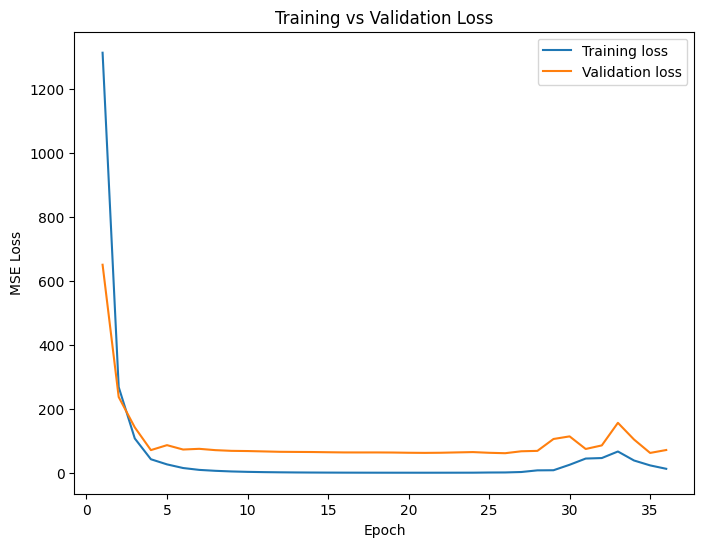

In [124]:
#Plot training vs validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs_range, train_loss, label="Training loss")
plt.plot(epochs_range, val_loss, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [125]:
# Predictions
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [126]:
# Evaluate model
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)
test_r2 = r2_score(y_test, test_preds)

train_mae = mean_absolute_error(y_train, train_preds)
val_mae = mean_absolute_error(y_val, val_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print("\nTrain Results: ")
print("RMSE:", train_rmse)
print("R2 Score:", train_r2)
print("MAE:", train_mae)

print("\nValidation Results: ")
print("RMSE:", val_rmse)
print("R2 Score:", val_r2)
print("MAE:", val_mae)


print("\nTest Results:")
print("RMSE:", test_rmse)
print("R2 Score:", val_r2)
print("MAE:", test_mae)


Train Results: 
RMSE: 1.5250909684361833
R2 Score: 0.9843937158584595
MAE: 1.0946654081344604

Validation Results: 
RMSE: 7.8120954485100125
R2 Score: 0.6489905714988708
MAE: 5.889073848724365

Test Results:
RMSE: 7.814874150976807
R2 Score: 0.6489905714988708
MAE: 6.532464981079102


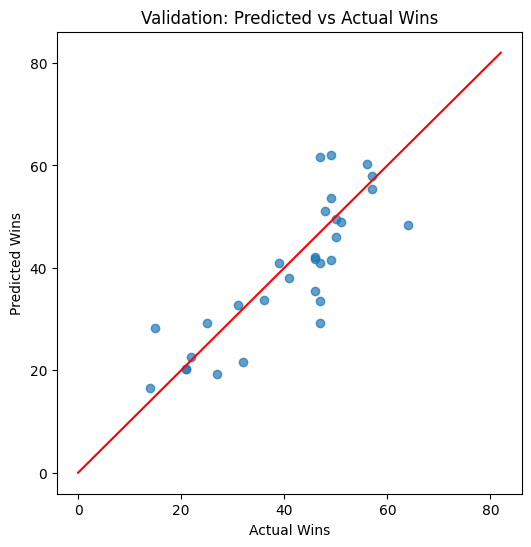

In [127]:
# Validation precdiction graph
plt.figure(figsize=(6,6))

plt.scatter(y_val, val_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Validation: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

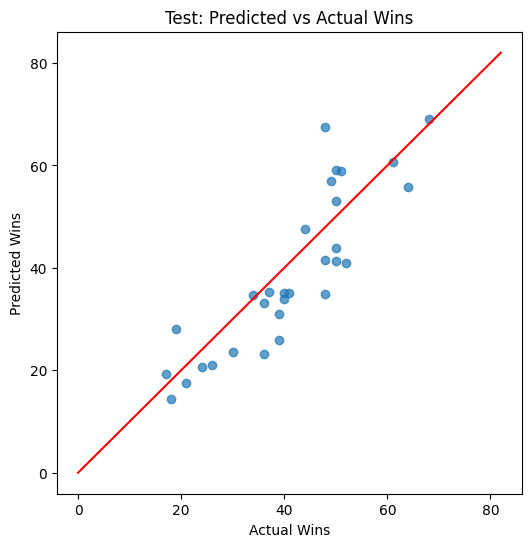

In [128]:
#Test Prediction Graph
plt.figure(figsize=(6,6))

plt.scatter(y_test, test_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Test: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

In [129]:
predictions = pd.DataFrame({
    "Actual Wins": y_test, 
    "Predicted Wins": test_preds.flatten()
})
print("\nSample Predictions")
print(predictions.head())


Sample Predictions
   Actual Wins  Predicted Wins
0         40.0       35.007221
1         61.0       60.568691
2         26.0       21.024096
3         19.0       28.144524
4         39.0       25.953239


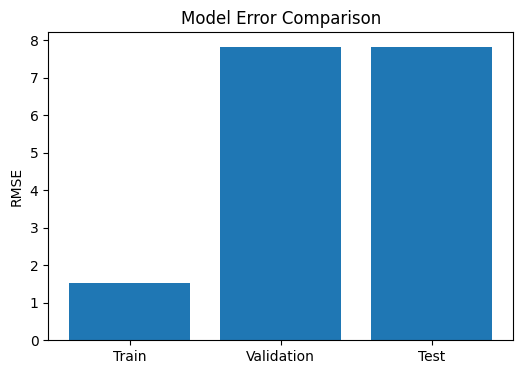

In [130]:
labels = ["Train", "Validation", "Test"]
errors = [train_rmse, val_rmse, test_rmse]

plt.figure(figsize=(6,4))

plt.bar(labels, errors)

plt.ylabel("RMSE")
plt.title("Model Error Comparison")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


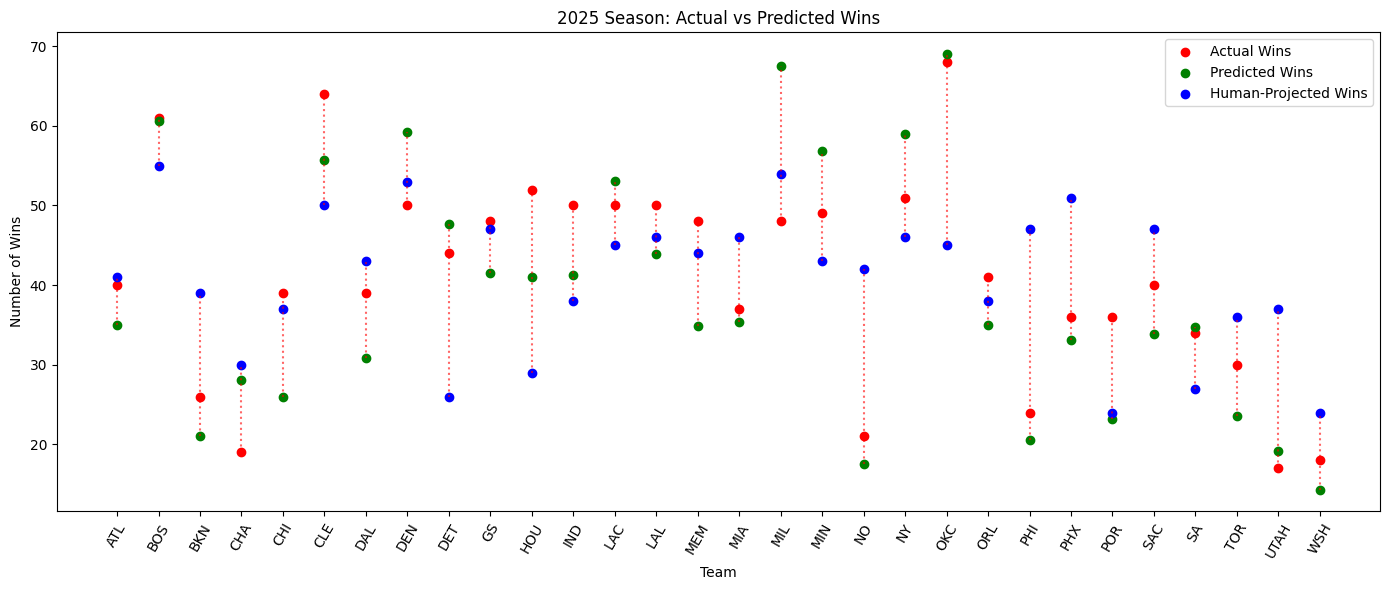

In [131]:
# Get 2005 season data
season_2025 = df[df["season"] == 2025].copy()

X_2025 = season_2025[feature_cols].fillna(0)
y_2025 = season_2025[target]

# Scale using the scaler used on training data
X_2025 = scaler.transform(X_2025)
X_2025 = np.array(X_2025, dtype=np.float32)

base_2025 = baseline_ref["espn_pred_wins"]

# Predict wins
pred_2025 = model.predict(X_2025).flatten()

teams = season_2025["team"].values

# Plot
plt.figure(figsize=(14,6))

plt.scatter(teams, y_2025, color="red", label="Actual Wins")
plt.scatter(teams, pred_2025, color="green", label="Predicted Wins")
plt.scatter(teams, base_2025, color="blue", label="Human-Projected Wins")

# Draw vertical dotted lines per team
x = np.arange(len(teams))
for i in range(len(x)):
    ymin = min(y_2025.iloc[i], pred_2025[i], base_2025.iloc[i])
    ymax = max(y_2025.iloc[i], pred_2025[i], base_2025.iloc[i])
    
    plt.vlines(x[i], ymin, ymax, colors="red", linestyles="dotted", alpha=0.6)


plt.xticks(rotation=60)
plt.ylabel("Number of Wins")
plt.xlabel("Team")
plt.title("2025 Season: Actual vs Predicted Wins")

plt.legend()
plt.tight_layout()

plt.show()